# 📂 ATS Resume Scoring System — Multi-Resume Batch Trainer

## Overview

This notebook reads **all PDF resumes** from your `data/` folder, extracts features from each one,
builds a searchable corpus, and produces:

- ✅ An ATS score for **every resume** against a given job description
- ✅ A ranked leaderboard of all candidates
- ✅ A trained **TF-IDF vectorizer + cosine similarity ranker** saved to disk
- ✅ A trained **Random Forest scoring model** (self-supervised)
- ✅ Batch visualizations and per-resume insight reports
- ✅ CSV export of all scores

### Project Folder Structure Expected
```
resume/
├── data/                    ← All 50+ PDF resumes go here
│   ├── candidate1.pdf
│   ├── candidate2.pdf
│   └── ...
├── ATS_MultiResume_Train_Score.ipynb   ← This notebook
```

### Score Components
| Component | Max |
|---|---|
| Keyword Match | 40 |
| Semantic Similarity | 30 |
| Skills Coverage | 10 |
| Experience Relevance | 15 |
| Formatting Quality | 5 |
| **Total** | **100** |

## Cell 1 — Install Dependencies

In [1]:
!pip install pdfplumber spacy sentence-transformers scikit-learn numpy pandas matplotlib tqdm joblib --quiet
!python -m spacy download en_core_web_sm --quiet
print('✅ Dependencies ready.')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✅ Dependencies ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 — Imports & Global Config

In [2]:
import os
import re
import glob
import json
import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import pdfplumber
import spacy
import joblib

from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ─── CONFIG — Edit these paths ────────────────────────────────────────────────
DATA_FOLDER   = 'data'          # Folder containing all resume PDFs
OUTPUT_FOLDER = 'ats_output'    # Where results, models, CSVs are saved
MODEL_DIR     = 'ats_models'    # Where trained models are saved

# Score weights (must sum to 100)
WEIGHTS = {
    'keyword':    40,
    'semantic':   30,
    'skills':     10,
    'experience': 15,
    'formatting':  5,
}

# Create output directories
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ─── Load NLP Models ──────────────────────────────────────────────────────────
print('Loading spaCy...')
nlp = spacy.load('en_core_web_sm')

print('Loading SentenceTransformer (downloads once)...')
sent_model = SentenceTransformer('all-MiniLM-L6-v2')

print('✅ All models loaded.')
print(f'   Data folder   : {os.path.abspath(DATA_FOLDER)}')
print(f'   Output folder : {os.path.abspath(OUTPUT_FOLDER)}')

Loading spaCy...
Loading SentenceTransformer (downloads once)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 854.78it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ All models loaded.
   Data folder   : d:\python\resume\data
   Output folder : d:\python\resume\ats_output


## Cell 3 — PDF Parsing Utilities

In [3]:
def extract_pdf_text(pdf_path: str) -> dict:
    """
    Extract text and metadata from a single PDF resume.

    Args:
        pdf_path: Path to the PDF file.

    Returns:
        Dict with keys: raw_text, page_count, has_tables, file_name.
    """
    raw_text = ''
    page_count = 0
    has_tables = False
    try:
        with pdfplumber.open(pdf_path) as pdf:
            page_count = len(pdf.pages)
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    raw_text += text + '\n'
                if page.extract_tables():
                    has_tables = True
    except Exception as e:
        print(f'  ⚠️  Failed to parse {os.path.basename(pdf_path)}: {e}')
    return {
        'file_name': os.path.basename(pdf_path),
        'file_path': pdf_path,
        'raw_text': raw_text,
        'page_count': page_count,
        'has_tables': has_tables,
    }


def clean_text(text: str) -> str:
    """
    Clean and normalize resume text.
    - Remove non-ASCII characters
    - Remove excessive whitespace
    - Lowercase
    """
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)   # non-ASCII
    text = re.sub(r'[\x80-\xFF]', ' ', text)       # extended ASCII
    text = re.sub(r'\s+', ' ', text).strip()        # whitespace
    return text.lower()


print('✅ PDF parsing utilities defined.')

✅ PDF parsing utilities defined.


## Cell 4 — Batch Load All Resumes from `data/` Folder

In [4]:
def load_all_resumes(data_folder: str) -> pd.DataFrame:
    """
    Load and parse all PDF files from the data folder.

    Args:
        data_folder: Path to folder containing resume PDFs.

    Returns:
        DataFrame with one row per resume and parsed fields.
    """
    pdf_paths = glob.glob(os.path.join(data_folder, '**', '*.pdf'), recursive=True)
    pdf_paths += glob.glob(os.path.join(data_folder, '*.pdf'))
    pdf_paths = list(set(pdf_paths))  # deduplicate

    if not pdf_paths:
        raise FileNotFoundError(
            f'No PDF files found in "{data_folder}". '
            f'Please place your resume PDFs in the "{data_folder}" folder.'
        )

    print(f'Found {len(pdf_paths)} PDF files. Parsing...')
    records = []
    for path in tqdm(pdf_paths, desc='Parsing PDFs'):
        record = extract_pdf_text(path)
        record['clean_text'] = clean_text(record['raw_text'])
        record['word_count'] = len(record['clean_text'].split())
        records.append(record)

    df = pd.DataFrame(records)
    # Drop completely empty resumes
    empty_mask = df['word_count'] < 20
    if empty_mask.sum() > 0:
        print(f'  ⚠️  Dropping {empty_mask.sum()} empty/unreadable PDFs.')
        df = df[~empty_mask].reset_index(drop=True)

    print(f'\n✅ Loaded {len(df)} resumes successfully.')
    print(f'   Avg word count : {df["word_count"].mean():.0f}')
    print(f'   With tables    : {df["has_tables"].sum()}')
    return df


# ─── Load all resumes ─────────────────────────────────────────────────────────
resume_df = load_all_resumes(DATA_FOLDER)
resume_df[['file_name', 'word_count', 'page_count', 'has_tables']].head(10)

Found 120 PDF files. Parsing...


Parsing PDFs: 100%|██████████| 120/120 [01:07<00:00,  1.77it/s]


✅ Loaded 120 resumes successfully.
   Avg word count : 923
   With tables    : 0


,file_name,word_count,page_count,has_tables
0,27485716.pdf,739,2,False
1,15791766.pdf,612,2,False
2,19850482.pdf,984,2,False
3,37242217.pdf,919,2,False
4,14789139.pdf,1164,2,False
5,27295996.pdf,919,2,False
6,17111768.pdf,1397,3,False
7,23527321.pdf,809,2,False
8,19201175.pdf,745,2,False
9,39413067.pdf,682,2,False


## Cell 5 — Define Your Job Description

In [5]:
# ─── PASTE YOUR JOB DESCRIPTION HERE ─────────────────────────────────────────
# You can change this to any JD and re-run from Cell 6 onwards.

JOB_DESCRIPTION = """
We are looking for a Senior RF Systems Engineer to join our satellite communications team.

Responsibilities:
- Design and develop RF hardware units including antennas, receivers, filters, and amplifiers.
- Generate cascade RF performance analyses including NF, Gain, IP3, 1dB compression, and spurious.
- Lead EVT, DVT, and PVT verification and validation processes.
- Define DFM procedures and requirements for subcontractors and suppliers.
- Perform Failure Analysis (FA) to drive root cause from system to unit level.
- Collaborate with cross-functional teams on satellite system design.
- Work with SQL databases and data analysis tools for system performance monitoring.
- Utilize spectrum analyzers, vector network analyzers, and signal analyzers.

Requirements:
- M.S. in Electrical Engineering or related field.
- 5+ years of experience in RF systems engineering.
- Proficiency in Python, MATLAB, C/C++.
- Experience with AWR Microwave Office or Ansoft Designer.
- Strong background in satellite communication systems.
- Familiarity with PCB design and SPICE simulation.
- Knowledge of LabVIEW, SQL, and data analysis.
"""

clean_jd = clean_text(JOB_DESCRIPTION)
print('✅ Job description loaded.')
print(f'   Word count: {len(clean_jd.split())}')

✅ Job description loaded.
   Word count: 165


## Cell 6 — Feature Extraction Functions

In [6]:
# ─── Skill patterns (extend for your domain) ──────────────────────────────────
SKILL_PATTERNS = [
    r'\bpython\b', r'\bmatlab\b', r'\bc\+\+\b', r'\bc/c\+\+\b',
    r'\bjava\b', r'\bsql\b', r'\blabview\b', r'\bspice\b',
    r'\bpcb\b', r'\brf\b', r'\bfpga\b', r'\bvhdl\b', r'\bverilog\b',
    r'\bawr\b', r'\bansoft\b', r'\bsas\b', r'\bspss\b',
    r'\bexcel\b', r'\bnumpy\b', r'\bpandas\b', r'\btensorflow\b',
    r'\bkeras\b', r'\bscikit\b', r'\bgit\b', r'\bdocker\b',
    r'\blinux\b', r'\baws\b', r'\bazure\b', r'\bgcp\b',
    r'\bjavascript\b', r'\bhtml\b', r'\bcss\b', r'\breact\b',
    r'\bnode\b', r'\bdjango\b', r'\bflask\b', r'\bspring\b',
    r'\bmachine learning\b', r'\bdeep learning\b', r'\bneural network\b',
    r'\bdata analysis\b', r'\bdata science\b', r'\bstatistics\b',
    r'\bagile\b', r'\bscrum\b', r'\bdevops\b', r'\bci/cd\b',
    r'\bkubernetes\b', r'\bterraform\b', r'\bansible\b',
]


def extract_keywords_spacy(text: str, top_n: int = 80) -> list:
    """Extract noun-based keywords from text using spaCy."""
    doc = nlp(text[:50000])  # spaCy limit guard
    keywords = set()
    for token in doc:
        if (not token.is_stop and not token.is_punct
                and token.is_alpha and len(token.text) > 2
                and token.pos_ in ('NOUN', 'PROPN', 'ADJ')):
            keywords.add(token.lemma_.lower())
    for chunk in doc.noun_chunks:
        c = chunk.text.strip().lower()
        if 2 <= len(c.split()) <= 4:
            keywords.add(c)
    for ent in doc.ents:
        if ent.label_ not in ('DATE', 'TIME', 'CARDINAL', 'ORDINAL', 'PERCENT'):
            keywords.add(ent.text.strip().lower())
    return list(keywords)[:top_n]


def match_skills(text: str, patterns: list) -> list:
    """Return list of skill pattern labels found in text."""
    found = []
    for p in patterns:
        if re.search(p, text, re.IGNORECASE):
            label = p.replace(r'\b', '').replace('\\', '').strip()
            found.append(label)
    return list(set(found))


def extract_years_experience(text: str) -> float:
    """Extract years of experience via regex, fallback to date-range estimation."""
    patterns = [
        r'(\d+)\+?\s*years?\s+of\s+experience',
        r'(\d+)\+?\s*years?\s+experience',
        r'experience\s+of\s+(\d+)\+?\s*years?',
        r'(\d+)\+?\s*years?\s+in\s+',
    ]
    for p in patterns:
        m = re.search(p, text, re.IGNORECASE)
        if m:
            return float(m.group(1))
    # Fallback: sum year ranges
    year_ranges = re.findall(
        r'(\d{4})\s*(?:to|-)\s*(\d{4}|current|present)', text, re.IGNORECASE
    )
    current_year = datetime.datetime.now().year
    total = 0.0
    for start, end in year_ranges:
        s = int(start)
        e = current_year if end.lower() in ('current', 'present') else int(end)
        total += max(0, e - s)
    return total


def special_char_ratio(text: str) -> float:
    """Return ratio of special characters to total characters."""
    if not text:
        return 0.0
    special = len(re.findall(r'[^a-zA-Z0-9\s.,;:\-/()]', text))
    return special / len(text)


print('✅ Feature extraction functions defined.')

✅ Feature extraction functions defined.


## Cell 7 — Build TF-IDF Corpus Model (Trained on All Resumes)

In [7]:
def train_tfidf_model(corpus: list, save_path: str = None) -> TfidfVectorizer:
    """
    Train a TF-IDF vectorizer on the entire resume corpus.

    This captures domain-specific vocabulary across all 50+ resumes,
    which improves keyword relevance scoring compared to a generic model.

    Args:
        corpus: List of cleaned resume text strings.
        save_path: Optional path to save the fitted vectorizer.

    Returns:
        Fitted TfidfVectorizer.
    """
    tfidf = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),        # unigrams + bigrams
        stop_words='english',
        sublinear_tf=True,          # dampen high-frequency terms
        min_df=2,                   # must appear in at least 2 resumes
        max_df=0.95,                # ignore terms in 95%+ of resumes (too generic)
    )
    tfidf.fit(corpus)
    if save_path:
        joblib.dump(tfidf, save_path)
        print(f'   Saved TF-IDF vectorizer → {save_path}')
    return tfidf


corpus = resume_df['clean_text'].tolist()
print(f'Training TF-IDF on {len(corpus)} resumes...')
tfidf_model = train_tfidf_model(
    corpus,
    save_path=os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl')
)

# Transform full corpus
corpus_tfidf_matrix = tfidf_model.transform(corpus)
print(f'✅ TF-IDF corpus matrix shape: {corpus_tfidf_matrix.shape}')
print(f'   Vocabulary size: {len(tfidf_model.vocabulary_)}')

Training TF-IDF on 120 resumes...
   Saved TF-IDF vectorizer → ats_models\tfidf_vectorizer.pkl
✅ TF-IDF corpus matrix shape: (120, 5000)
   Vocabulary size: 5000


## Cell 8 — Generate Semantic Embeddings for All Resumes

In [8]:
def generate_embeddings(texts: list, model: SentenceTransformer,
                        batch_size: int = 32, max_chars: int = 3000) -> np.ndarray:
    """
    Generate sentence embeddings for a list of texts in batches.

    Args:
        texts: List of text strings.
        model: Loaded SentenceTransformer.
        batch_size: Number of texts per encoding batch.
        max_chars: Truncate each text to this many characters.

    Returns:
        2D numpy array of shape (n_texts, embedding_dim).
    """
    truncated = [t[:max_chars] for t in texts]
    embeddings = model.encode(
        truncated,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    return embeddings


print('Generating semantic embeddings for all resumes...')
resume_embeddings = generate_embeddings(corpus, sent_model)

# Save embeddings for reuse
np.save(os.path.join(MODEL_DIR, 'resume_embeddings.npy'), resume_embeddings)
print(f'✅ Embeddings shape: {resume_embeddings.shape}')
print(f'   Saved → {MODEL_DIR}/resume_embeddings.npy')

Generating semantic embeddings for all resumes...


Batches: 100%|██████████| 4/4 [00:03<00:00,  1.23it/s]

✅ Embeddings shape: (120, 384)
   Saved → ats_models/resume_embeddings.npy


## Cell 9 — Per-Resume Feature Extraction (All 50+ Resumes)

In [9]:
def extract_resume_features(row: pd.Series, jd_keywords: list,
                            jd_skills: list) -> dict:
    """
    Extract all raw features for a single resume row.

    Args:
        row: DataFrame row with clean_text, raw_text, etc.
        jd_keywords: Keywords extracted from job description.
        jd_skills: Skills extracted from job description.

    Returns:
        Dict of raw feature values.
    """
    text = row['clean_text']
    raw  = row['raw_text']

    # Keyword match
    matched_kw = [kw for kw in jd_keywords if kw in text]
    kw_ratio   = len(matched_kw) / max(len(jd_keywords), 1)

    # Skills match
    resume_skills   = match_skills(text, SKILL_PATTERNS)
    matched_skills  = [s for s in jd_skills if s in resume_skills]
    skill_ratio     = len(matched_skills) / max(len(jd_skills), 1)

    # Experience
    resume_years = extract_years_experience(text)

    # Formatting signals
    wc           = row['word_count']
    has_tables   = int(row['has_tables'])
    spec_ratio   = special_char_ratio(raw)

    return {
        'kw_ratio':         kw_ratio,
        'matched_keywords': len(matched_kw),
        'total_keywords':   len(jd_keywords),
        'skill_ratio':      skill_ratio,
        'matched_skills':   len(matched_skills),
        'resume_skills':    resume_skills,
        'missing_skills':   [s for s in jd_skills if s not in resume_skills],
        'resume_years':     resume_years,
        'word_count':       wc,
        'has_tables':       has_tables,
        'special_char_ratio': spec_ratio,
    }


# ─── Pre-compute JD features once ─────────────────────────────────────────────
print('Extracting JD keywords...')
jd_keywords = extract_keywords_spacy(clean_jd, top_n=80)
jd_skills   = match_skills(clean_jd, SKILL_PATTERNS)
required_years = extract_years_experience(clean_jd)

print(f'   JD keywords : {len(jd_keywords)}')
print(f'   JD skills   : {jd_skills}')
print(f'   Required yrs: {required_years}')

print('\nExtracting features from all resumes...')
feature_rows = []
for _, row in tqdm(resume_df.iterrows(), total=len(resume_df), desc='Features'):
    feat = extract_resume_features(row, jd_keywords, jd_skills)
    feature_rows.append(feat)

features_df = pd.DataFrame(feature_rows)
print(f'\n✅ Feature matrix shape: {features_df.shape}')
features_df.head(5)

Extracting JD keywords...
   JD keywords : 80
   JD skills   : ['pcb', 'rf', 'python', 'sql', 'awr', 'ansoft', 'data analysis', 'matlab', 'labview', 'spice']
   Required yrs: 5.0

Extracting features from all resumes...


Features: 100%|██████████| 120/120 [00:00<00:00, 161.28it/s]


✅ Feature matrix shape: (120, 11)


,kw_ratio,matched_keywords,total_keywords,skill_ratio,matched_skills,resume_skills,missing_skills,resume_years,word_count,has_tables,special_char_ratio
0,0.1875,15,80,0.0,0,[],"[pcb, rf, python, sql, awr, ansoft, data analy...",0.0,739,0,0.004028
1,0.2000,16,80,0.0,0,[agile],"[pcb, rf, python, sql, awr, ansoft, data analy...",9.0,612,0,0.003989
2,0.1875,15,80,0.0,0,[],"[pcb, rf, python, sql, awr, ansoft, data analy...",0.0,984,0,0.001407
3,0.2500,20,80,0.1,1,"[linux, java, sql, javascript, css]","[pcb, rf, python, awr, ansoft, data analysis, ...",10.0,919,0,0.003455
4,0.2500,20,80,0.1,1,[sql],"[pcb, rf, python, awr, ansoft, data analysis, ...",13.0,1164,0,0.003266


## Cell 10 — Compute All Component Scores

In [10]:
def compute_all_scores(
    features_df: pd.DataFrame,
    resume_embeddings: np.ndarray,
    jd_text: str,
    sent_model: SentenceTransformer,
    required_years: float,
    weights: dict
) -> pd.DataFrame:
    """
    Compute 5-component ATS scores for all resumes.

    Args:
        features_df: Pre-extracted feature DataFrame.
        resume_embeddings: Embedding matrix for all resumes.
        jd_text: Cleaned job description text.
        sent_model: SentenceTransformer model.
        required_years: Years of experience required by JD.
        weights: Dict of max scores per component.

    Returns:
        DataFrame with all component scores and final ATS score.
    """
    scores = pd.DataFrame()

    # ── 1. Keyword Match Score (0–40) ─────────────────────────────────────────
    scores['keyword_score'] = (features_df['kw_ratio'] * weights['keyword']).round(2)

    # ── 2. Semantic Similarity Score (0–30) ───────────────────────────────────
    print('Computing semantic similarity for all resumes vs JD...')
    jd_emb = sent_model.encode([jd_text[:3000]], convert_to_numpy=True)
    sims   = cosine_similarity(resume_embeddings, jd_emb).flatten()
    scores['semantic_score'] = (sims * weights['semantic']).round(2)
    scores['cosine_sim']     = sims.round(4)

    # ── 3. Skills Coverage Score (0–10) ───────────────────────────────────────
    scores['skills_score'] = (features_df['skill_ratio'] * weights['skills']).round(2)

    # ── 4. Experience Relevance Score (0–15) ──────────────────────────────────
    def exp_score(resume_yrs: float, req_yrs: float, max_s: float) -> float:
        if req_yrs <= 0:
            return max_s if resume_yrs > 0 else max_s * 0.5
        return round(min(resume_yrs / req_yrs, 1.0) * max_s, 2)

    scores['experience_score'] = features_df['resume_years'].apply(
        lambda y: exp_score(y, required_years, weights['experience'])
    )
    scores['resume_years'] = features_df['resume_years']

    # ── 5. Formatting Score (0–5) ─────────────────────────────────────────────
    def fmt_score(row: pd.Series, max_s: float) -> float:
        s = max_s
        if row['has_tables']:              s -= 2
        if row['special_char_ratio'] > 0.05: s -= 1
        if row['word_count'] < 300:        s -= 2
        return max(0.0, s)

    scores['formatting_score'] = features_df.apply(
        lambda r: fmt_score(r, weights['formatting']), axis=1
    )

    # ── Final ATS Score ───────────────────────────────────────────────────────
    score_cols = ['keyword_score', 'semantic_score', 'skills_score',
                  'experience_score', 'formatting_score']
    scores['ats_score'] = scores[score_cols].sum(axis=1).clip(upper=100).round(2)

    # Grade
    def grade(s):
        if s >= 85: return 'Excellent'
        if s >= 70: return 'Good'
        if s >= 50: return 'Average'
        return 'Needs Work'

    scores['grade'] = scores['ats_score'].apply(grade)
    scores['matched_keywords'] = features_df['matched_keywords'].values
    scores['matched_skills']   = features_df['matched_skills'].values
    scores['missing_skills']   = features_df['missing_skills'].values
    scores['word_count']       = features_df['word_count'].values

    return scores


scores_df = compute_all_scores(
    features_df, resume_embeddings, clean_jd,
    sent_model, required_years, WEIGHTS
)

print('\n✅ Scores computed for all resumes.')
scores_df[['ats_score', 'keyword_score', 'semantic_score',
           'skills_score', 'experience_score', 'formatting_score', 'grade']].describe()

Computing semantic similarity for all resumes vs JD...

✅ Scores computed for all resumes.


,ats_score,keyword_score,semantic_score,skills_score,experience_score,formatting_score
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,35.501333,8.795833,10.580500,0.666667,10.475000,4.983333
std,9.096717,2.738993,2.314975,1.055863,6.713792,0.182574
min,15.850000,3.500000,3.890000,0.000000,0.000000,3.000000
25%,28.117500,7.500000,9.100000,0.000000,0.000000,5.000000
50%,37.880000,8.500000,10.685000,0.000000,15.000000,5.000000
75%,41.872500,10.000000,12.030000,1.000000,15.000000,5.000000
max,77.890000,26.000000,22.889999,9.000000,15.000000,5.000000


## Cell 11 — Build Master Results DataFrame

In [11]:
# Merge resume metadata with scores
results_df = pd.concat([
    resume_df[['file_name', 'page_count', 'has_tables']].reset_index(drop=True),
    scores_df.reset_index(drop=True)
], axis=1)

# Sort by ATS score descending
results_df = results_df.sort_values('ats_score', ascending=False).reset_index(drop=True)
results_df.index += 1  # rank starts at 1
results_df.index.name = 'rank'

# Save to CSV
csv_path = os.path.join(OUTPUT_FOLDER, 'ats_scores_all_resumes.csv')
results_df.to_csv(csv_path)
print(f'✅ Results saved → {csv_path}')

# Display top 20
display_cols = ['file_name', 'ats_score', 'keyword_score', 'semantic_score',
                'skills_score', 'experience_score', 'formatting_score',
                'resume_years', 'word_count', 'grade']
print('\n🏆 TOP 20 CANDIDATES:')
results_df[display_cols].head(20)

✅ Results saved → ats_output\ats_scores_all_resumes.csv

🏆 TOP 20 CANDIDATES:


,file_name,ats_score,keyword_score,semantic_score,skills_score,experience_score,formatting_score,resume_years,word_count,grade
rank,,,,,,,,,,
1,10265057.pdf,77.89,26.0,22.889999,9.0,15.0,5,12.0,702,Good
2,22450718.pdf,49.63,16.0,13.630000,0.0,15.0,5,5.0,991,Needs Work
3,46260230.pdf,46.51,12.0,14.510000,0.0,15.0,5,22.0,1323,Needs Work
4,19796840.pdf,46.38,15.5,9.880000,1.0,15.0,5,10.0,2035,Needs Work
5,27295996.pdf,45.22,11.0,12.220000,2.0,15.0,5,11.0,919,Needs Work
6,15651486.pdf,45.16,9.5,13.660000,2.0,15.0,5,11.0,884,Needs Work
7,11584809.pdf,44.56,12.0,12.560000,0.0,15.0,5,12.0,657,Needs Work
8,17111768.pdf,44.31,11.5,11.810000,1.0,15.0,5,16.0,1397,Needs Work
9,10247517.pdf,44.28,12.5,10.780000,1.0,15.0,5,13.0,883,Needs Work


## Cell 12 — Train Random Forest Scoring Model (Self-Supervised)

We use the component scores as features and the final ATS score as the target.
This lets the model learn feature importance and can be used to predict scores on new resumes faster (without re-computing semantic similarity every time).

In [12]:
def train_rf_scorer(results_df: pd.DataFrame, model_dir: str) -> RandomForestRegressor:
    """
    Train a Random Forest regressor to predict ATS scores from component features.

    Self-supervised: uses the rule-based ATS scores as ground truth labels.
    In production, replace labels with human-rated scores for better accuracy.

    Args:
        results_df: Results DataFrame with component scores.
        model_dir: Directory to save the trained model.

    Returns:
        Fitted RandomForestRegressor.
    """
    feature_cols = [
        'keyword_score', 'semantic_score', 'skills_score',
        'experience_score', 'formatting_score',
        'resume_years', 'word_count', 'cosine_sim',
        'matched_keywords', 'matched_skills'
    ]

    X = results_df[feature_cols].fillna(0).values
    y = results_df['ats_score'].values

    # Need enough samples for a meaningful split
    if len(X) >= 10:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
    else:
        X_train, X_test, y_train, y_test = X, X, y, y

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    train_score = rf.score(X_train, y_train)
    test_score  = rf.score(X_test, y_test)
    print(f'   Train R² : {train_score:.4f}')
    print(f'   Test  R² : {test_score:.4f}')

    # Feature importances
    importance_df = pd.DataFrame({
        'feature':    feature_cols,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    print('\n   Feature Importances:')
    print(importance_df.to_string(index=False))

    # Save model
    model_path = os.path.join(model_dir, 'rf_ats_scorer.pkl')
    joblib.dump({'model': rf, 'features': feature_cols}, model_path)
    print(f'\n   Saved RF model → {model_path}')

    return rf, feature_cols


print('Training Random Forest ATS scorer...')
rf_model, rf_features = train_rf_scorer(results_df, MODEL_DIR)
print('\n✅ Random Forest model trained and saved.')

Training Random Forest ATS scorer...
   Train R² : 0.9889
   Test  R² : 0.6312

   Feature Importances:
         feature  importance
experience_score    0.423343
    resume_years    0.403754
matched_keywords    0.058744
   keyword_score    0.047177
  semantic_score    0.031943
      cosine_sim    0.029388
      word_count    0.004040
    skills_score    0.000919
  matched_skills    0.000694
formatting_score    0.000000

   Saved RF model → ats_models\rf_ats_scorer.pkl

✅ Random Forest model trained and saved.


## Cell 13 — Candidate Leaderboard

In [13]:
def print_leaderboard(results_df: pd.DataFrame, top_n: int = 15) -> None:
    """Print a formatted leaderboard of top candidates."""
    print('=' * 80)
    print(f'{'RANK':<5} {'RESUME FILE':<35} {'ATS SCORE':>9} {'GRADE':<12}')
    print('=' * 80)
    for rank, (_, row) in enumerate(results_df.head(top_n).iterrows(), 1):
        emoji = '🥇' if rank == 1 else '🥈' if rank == 2 else '🥉' if rank == 3 else '  '
        print(f'{emoji}{rank:<4} {row["file_name"]:<35} {row["ats_score"]:>8.1f}  {row["grade"]}')
    print('=' * 80)
    print(f'\nTotal candidates scored: {len(results_df)}')
    print(f'Average ATS score      : {results_df["ats_score"].mean():.1f}')
    print(f'Highest score          : {results_df["ats_score"].max():.1f}')
    print(f'Lowest score           : {results_df["ats_score"].min():.1f}')


print_leaderboard(results_df)

RANK  RESUME FILE                         ATS SCORE GRADE       
🥇1    10265057.pdf                            77.9  Good
🥈2    22450718.pdf                            49.6  Needs Work
🥉3    46260230.pdf                            46.5  Needs Work
  4    19796840.pdf                            46.4  Needs Work
  5    27295996.pdf                            45.2  Needs Work
  6    15651486.pdf                            45.2  Needs Work
  7    11584809.pdf                            44.6  Needs Work
  8    17111768.pdf                            44.3  Needs Work
  9    10247517.pdf                            44.3  Needs Work
  10   18067556.pdf                            44.1  Needs Work
  11   26801767.pdf                            43.7  Needs Work
  12   20674668.pdf                            43.5  Needs Work
  13   11580408.pdf                            43.4  Needs Work
  14   25959103.pdf                            43.3  Needs Work
  15   30223363.pdf                            4

## Cell 14 — Batch Visualizations

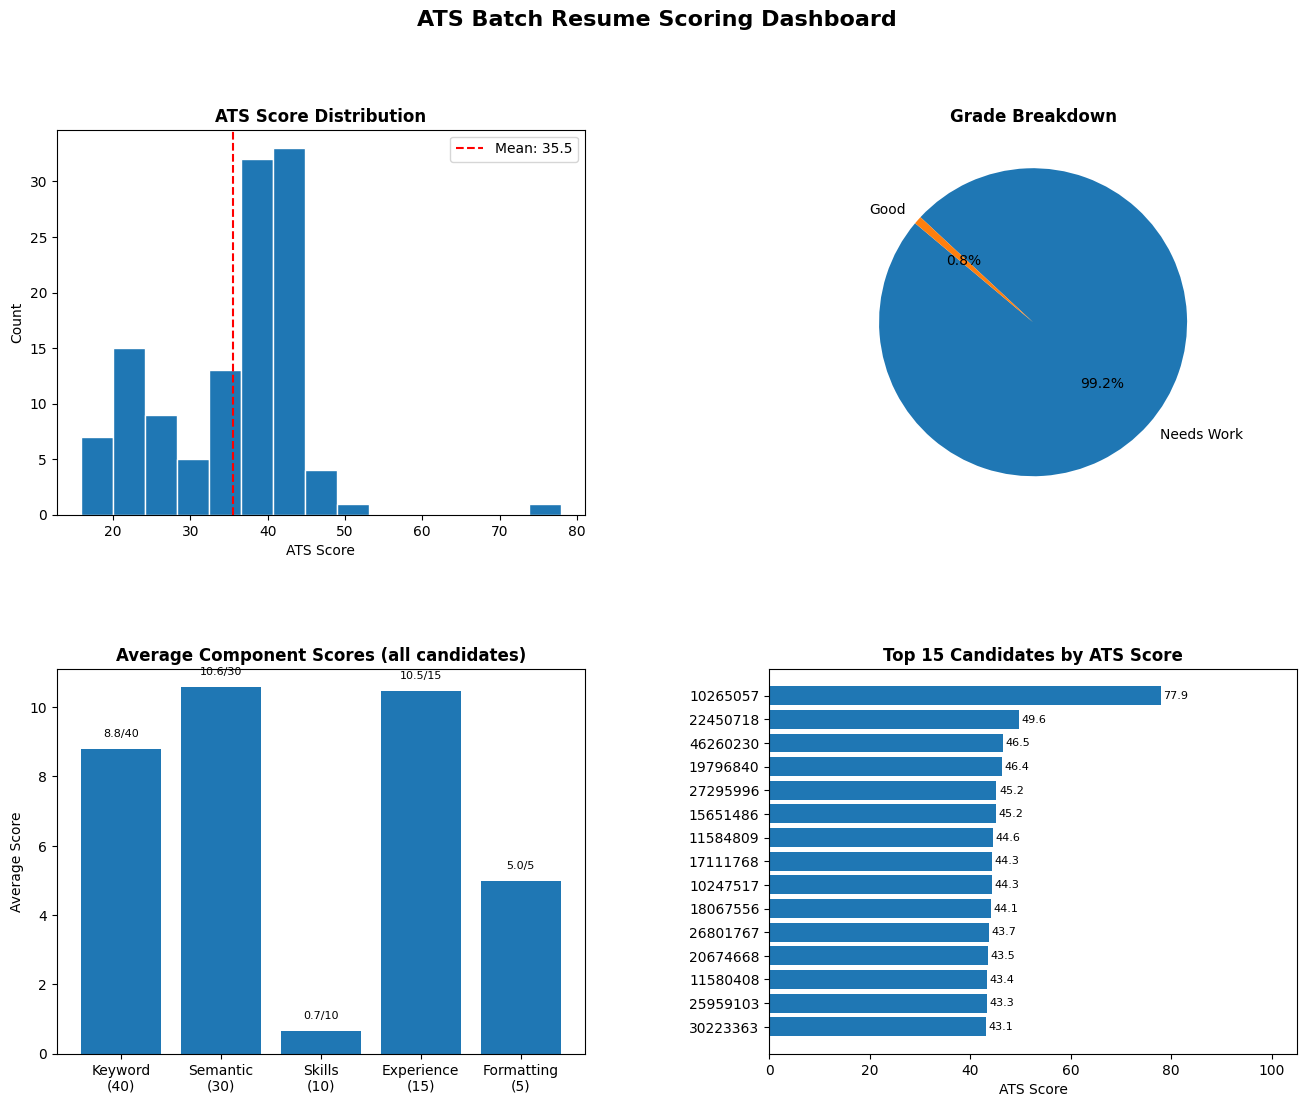

✅ Dashboard saved → ats_output/ats_dashboard.png


In [14]:
def plot_batch_dashboard(results_df: pd.DataFrame, output_folder: str) -> None:
    """
    Generate a 4-panel dashboard for batch resume analysis.

    Panels:
      1. ATS Score distribution histogram
      2. Grade breakdown pie chart
      3. Component score averages bar chart
      4. Top 15 candidates ranked bar chart
    """
    fig = plt.figure(figsize=(16, 12))
    fig.suptitle('ATS Batch Resume Scoring Dashboard', fontsize=16, fontweight='bold', y=0.98)
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    # ── Panel 1: Score Distribution ──────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(results_df['ats_score'], bins=15, edgecolor='white')
    ax1.axvline(results_df['ats_score'].mean(), color='red',
                linestyle='--', label=f'Mean: {results_df["ats_score"].mean():.1f}')
    ax1.set_title('ATS Score Distribution', fontweight='bold')
    ax1.set_xlabel('ATS Score')
    ax1.set_ylabel('Count')
    ax1.legend()

    # ── Panel 2: Grade Breakdown ──────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    grade_counts = results_df['grade'].value_counts()
    ax2.pie(grade_counts.values, labels=grade_counts.index,
            autopct='%1.1f%%', startangle=140)
    ax2.set_title('Grade Breakdown', fontweight='bold')

    # ── Panel 3: Average Component Scores ─────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    comp_cols  = ['keyword_score', 'semantic_score', 'skills_score',
                  'experience_score', 'formatting_score']
    comp_names = ['Keyword\n(40)', 'Semantic\n(30)', 'Skills\n(10)',
                  'Experience\n(15)', 'Formatting\n(5)']
    comp_avgs  = results_df[comp_cols].mean()
    comp_maxes = [40, 30, 10, 15, 5]
    bars = ax3.bar(comp_names, comp_avgs)
    for bar, mx, val in zip(bars, comp_maxes, comp_avgs):
        ax3.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}/{mx}', ha='center', va='bottom', fontsize=8)
    ax3.set_title('Average Component Scores (all candidates)', fontweight='bold')
    ax3.set_ylabel('Average Score')

    # ── Panel 4: Top 15 Candidates ────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    top15 = results_df.head(15)
    labels = [f.replace('.pdf', '')[:20] for f in top15['file_name']]
    ax4.barh(labels[::-1], top15['ats_score'].values[::-1])
    ax4.set_xlabel('ATS Score')
    ax4.set_title('Top 15 Candidates by ATS Score', fontweight='bold')
    ax4.set_xlim(0, 105)
    for i, v in enumerate(top15['ats_score'].values[::-1]):
        ax4.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=8)

    plt.savefig(os.path.join(output_folder, 'ats_dashboard.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Dashboard saved → {output_folder}/ats_dashboard.png')


plot_batch_dashboard(results_df, OUTPUT_FOLDER)

## Cell 15 — Individual Resume Deep-Dive Report

In [15]:
def resume_deep_dive(file_name: str, results_df: pd.DataFrame,
                     resume_df: pd.DataFrame, jd_keywords: list) -> None:
    """
    Print a detailed ATS report for a specific resume.

    Args:
        file_name: PDF file name (e.g., 'candidate1.pdf').
        results_df: Master results DataFrame (ranked).
        resume_df: Raw resume DataFrame.
        jd_keywords: JD keyword list for gap analysis.
    """
    row = results_df[results_df['file_name'] == file_name]
    if row.empty:
        print(f'❌ File "{file_name}" not found in results.')
        return
    row = row.iloc[0]
    rank = results_df.index[results_df['file_name'] == file_name].tolist()[0]

    # Get resume text for keyword gap
    res_text_row = resume_df[resume_df['file_name'] == file_name]
    res_text = res_text_row['clean_text'].values[0] if not res_text_row.empty else ''
    missing_kw = [kw for kw in jd_keywords if kw not in res_text][:15]

    print('=' * 60)
    print(f'  CANDIDATE REPORT: {file_name}')
    print(f'  Rank: #{rank} of {len(results_df)}  |  Grade: {row["grade"]}')
    print('=' * 60)
    print(f'  ATS Score         : {row["ats_score"]:>6.1f} / 100')
    print(f'  Keyword Match     : {row["keyword_score"]:>6.1f} / 40')
    print(f'  Semantic Sim.     : {row["semantic_score"]:>6.1f} / 30  (cosine: {row["cosine_sim"]:.3f})')
    print(f'  Skills Coverage   : {row["skills_score"]:>6.1f} / 10')
    print(f'  Experience Match  : {row["experience_score"]:>6.1f} / 15  (~{row["resume_years"]:.0f} yrs)')
    print(f'  Formatting        : {row["formatting_score"]:>6.1f} / 5')
    print('-' * 60)
    print(f'  Keywords matched  : {row["matched_keywords"]} / {len(jd_keywords)}')
    print(f'  Skills matched    : {row["matched_skills"]}')
    print(f'  Missing skills    : {row["missing_skills"]}')
    print(f'  Word count        : {int(row["word_count"])}')
    print('\n  📌 Missing Keywords (add to resume):')
    for kw in missing_kw:
        print(f'    • {kw}')
    print('=' * 60)


# ─── Demo: deep-dive on the #1 ranked candidate ───────────────────────────────
top_candidate = results_df.iloc[0]['file_name']
print(f'Deep-dive report for top candidate: {top_candidate}\n')
resume_deep_dive(top_candidate, results_df, resume_df, jd_keywords)

Deep-dive report for top candidate: 10265057.pdf

  CANDIDATE REPORT: 10265057.pdf
  Rank: #1 of 120  |  Grade: Good
  ATS Score         :   77.9 / 100
  Keyword Match     :   26.0 / 40
  Semantic Sim.     :   22.9 / 30  (cosine: 0.763)
  Skills Coverage   :    9.0 / 10
  Experience Match  :   15.0 / 15  (~12 yrs)
  Formatting        :    5.0 / 5
------------------------------------------------------------
  Keywords matched  : 52 / 80
  Skills matched    : 9
  Missing skills    : ['data analysis']
  Word count        : 702

  📌 Missing Keywords (add to resume):
    • knowledge
    • - strong background
    • - knowledge
    • our satellite communications team
    • rf performance analyses
    • - proficiency
    • monitoring
    • strong
    • validation processes
    • vector network analyzers
    • failure analysis
    • compression
    • simulation
    • year
    • system performance monitoring


## Cell 16 — Score Any New Resume (Inference Pipeline)

In [16]:
def score_new_resume(pdf_path: str, job_description: str) -> dict:
    """
    Score a brand-new resume PDF against a job description.
    Uses all pretrained models (TF-IDF, SentenceTransformer, RF).

    Args:
        pdf_path: Path to new resume PDF.
        job_description: Raw JD text.

    Returns:
        Dict with all scores and suggestions.
    """
    # Parse
    parsed  = extract_pdf_text(pdf_path)
    clean   = clean_text(parsed['raw_text'])
    clean_j = clean_text(job_description)

    # JD features
    kw   = extract_keywords_spacy(clean_j)
    jd_s = match_skills(clean_j, SKILL_PATTERNS)
    req_y = extract_years_experience(clean_j)

    # Resume features
    matched_kw  = [k for k in kw if k in clean]
    res_skills  = match_skills(clean, SKILL_PATTERNS)
    matched_sk  = [s for s in jd_s if s in res_skills]
    miss_sk     = [s for s in jd_s if s not in res_skills]
    res_years   = extract_years_experience(clean)
    spec_ratio  = special_char_ratio(parsed['raw_text'])
    wc          = len(clean.split())

    # Scores
    kw_score  = round((len(matched_kw) / max(len(kw), 1)) * WEIGHTS['keyword'], 2)

    res_emb   = sent_model.encode([clean[:3000]], convert_to_numpy=True)
    jd_emb    = sent_model.encode([clean_j[:3000]], convert_to_numpy=True)
    sim       = float(cosine_similarity(res_emb, jd_emb)[0][0])
    sem_score = round(sim * WEIGHTS['semantic'], 2)

    sk_score  = round((len(matched_sk) / max(len(jd_s), 1)) * WEIGHTS['skills'], 2)

    if req_y <= 0:
        exp_score = WEIGHTS['experience'] if res_years > 0 else WEIGHTS['experience'] * 0.5
    else:
        exp_score = round(min(res_years / req_y, 1.0) * WEIGHTS['experience'], 2)

    fmt = WEIGHTS['formatting']
    if parsed['has_tables']:     fmt -= 2
    if spec_ratio > 0.05:        fmt -= 1
    if wc < 300:                 fmt -= 2
    fmt_score = max(0, fmt)

    ats = min(kw_score + sem_score + sk_score + exp_score + fmt_score, 100)

    result = {
        'file': os.path.basename(pdf_path),
        'ats_score': round(ats, 2),
        'keyword_score': kw_score,
        'semantic_score': sem_score,
        'skills_score': sk_score,
        'experience_score': exp_score,
        'formatting_score': fmt_score,
        'resume_years': res_years,
        'matched_keywords': len(matched_kw),
        'missing_skills': miss_sk,
    }

    # Print report
    print('=' * 55)
    print(f'  ATS SCORE: {ats:.1f} / 100')
    print('=' * 55)
    print(f'  Keyword Match     : {kw_score} / {WEIGHTS["keyword"]}')
    print(f'  Semantic Sim.     : {sem_score} / {WEIGHTS["semantic"]}')
    print(f'  Skills Coverage   : {sk_score} / {WEIGHTS["skills"]}')
    print(f'  Experience Match  : {exp_score} / {WEIGHTS["experience"]}')
    print(f'  Formatting        : {fmt_score} / {WEIGHTS["formatting"]}')
    print('-' * 55)
    print(f'  Missing skills: {miss_sk}')
    print('=' * 55)

    return result


# ─── Example: score the uploaded resume from earlier ──────────────────────────
# Uncomment and set path to test on any new PDF:
# new_result = score_new_resume('path/to/new_resume.pdf', JOB_DESCRIPTION)

print('✅ score_new_resume() is ready. Call it with any PDF path + JD string.')

✅ score_new_resume() is ready. Call it with any PDF path + JD string.


## Cell 17 — Save Final Summary Report

In [17]:
def save_summary_report(results_df: pd.DataFrame, output_folder: str,
                        job_description: str) -> None:
    """Save a human-readable text summary of the batch scoring run."""
    report_path = os.path.join(output_folder, 'ats_summary_report.txt')
    now = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    with open(report_path, 'w') as f:
        f.write('ATS BATCH RESUME SCORING REPORT\n')
        f.write(f'Generated: {now}\n')
        f.write('=' * 60 + '\n')
        f.write(f'Total resumes scored : {len(results_df)}\n')
        f.write(f'Average ATS score    : {results_df["ats_score"].mean():.1f}\n')
        f.write(f'Highest score        : {results_df["ats_score"].max():.1f} ({results_df.iloc[0]["file_name"]})\n')
        f.write(f'Lowest score         : {results_df["ats_score"].min():.1f}\n')
        f.write('\nGrade distribution:\n')
        for grade, cnt in results_df['grade'].value_counts().items():
            f.write(f'  {grade:<15}: {cnt}\n')
        f.write('\n' + '=' * 60 + '\n')
        f.write('FULL RANKED RESULTS:\n')
        f.write('=' * 60 + '\n')
        for rank, (_, row) in enumerate(results_df.iterrows(), 1):
            f.write(
                f'{rank:>3}. {row["file_name"]:<35} '
                f'ATS={row["ats_score"]:>5.1f}  '
                f'KW={row["keyword_score"]:>4.1f}  '
                f'SEM={row["semantic_score"]:>4.1f}  '
                f'SKL={row["skills_score"]:>4.1f}  '
                f'EXP={row["experience_score"]:>4.1f}  '
                f'FMT={row["formatting_score"]:>3.1f}  '
                f'[{row["grade"]}]\n'
            )

    print(f'✅ Summary report saved → {report_path}')


save_summary_report(results_df, OUTPUT_FOLDER, JOB_DESCRIPTION)

print('\n🎉 All done! Files saved to:', os.path.abspath(OUTPUT_FOLDER))
print('   ├── ats_scores_all_resumes.csv   → Full scored results')
print('   ├── ats_dashboard.png            → Batch visualization')
print('   └── ats_summary_report.txt       → Human-readable report')
print('\n   Models saved to:', os.path.abspath(MODEL_DIR))
print('   ├── tfidf_vectorizer.pkl         → Trained TF-IDF model')
print('   ├── resume_embeddings.npy        → All resume embeddings')
print('   └── rf_ats_scorer.pkl            → Trained Random Forest scorer')

✅ Summary report saved → ats_output\ats_summary_report.txt

🎉 All done! Files saved to: d:\python\resume\ats_output
   ├── ats_scores_all_resumes.csv   → Full scored results
   ├── ats_dashboard.png            → Batch visualization
   └── ats_summary_report.txt       → Human-readable report

   Models saved to: d:\python\resume\ats_models
   ├── tfidf_vectorizer.pkl         → Trained TF-IDF model
   ├── resume_embeddings.npy        → All resume embeddings
   └── rf_ats_scorer.pkl            → Trained Random Forest scorer


## Cell 18 — Limitations & Next Steps

### ⚠️ Known Limitations

1. **Self-supervised labels** — The Random Forest is trained on rule-based scores, not human ratings. For production use, collect recruiter-rated labels and retrain.

2. **No cross-resume calibration** — Scores are computed independently per resume vs. the JD. There is no normalization relative to the cohort unless you explicitly do so.

3. **PDF quality matters** — Scanned/image-based PDFs return no text. Use OCR (e.g., `pytesseract`) for such files.

4. **Single JD per run** — Changing the JD requires re-running from Cell 5 onwards. The embeddings and TF-IDF model can be reused.

5. **Domain-specific skill list** — The hardcoded `SKILL_PATTERNS` must be tuned to the industry for accurate skills scoring.

### 💡 Recommended Improvements

- **Add human labels**: Have recruiters rate each resume 1–10 and use that as the RF training target.
- **Section-aware parsing**: Score experience, education, and skills sections separately.
- **OCR support**: Add `pytesseract` fallback for scanned PDFs.
- **Multi-JD scoring**: Loop over multiple JDs and produce a candidate × JD scoring matrix.
- **Fine-tune embeddings**: Use a domain-specific fine-tuned model (e.g., `jjzha/jobbert-base-cased`) for better semantic alignment.